# Recap
It's the continuation of 03.stage2_supervised_instruction_finetuning.ipynb. In this section, we will perform preference-based finetuning on the model checkpoint that we generated in stage2.

In [1]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -U peft bitsandbytes transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 44.2 MB/s eta 0:00:00


In [3]:
!pip install -U trl  #transformer reinforecement learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 518.9/518.9 kB 11.1 MB/s eta 0:00:00


In [4]:
!pip install PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 119.3 MB/s eta 0:00:00


In [5]:
# this path is an output from stage#2
# this is the instruction-fine tunned model.
base_model_name = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
stage1_ft_model_name = "tinyllama-pharma-unsupervised"
stage2_ft_model_name = "tinyllama-pharma-instruction"
ft_model_name = "tinyllama-pharma-preferenced"
models_dir = "/content/drive/MyDrive/models"
stage1_model_path = f"{models_dir}/{stage1_ft_model_name}/checkpoint-100"
stage2_model_path = f"{models_dir}/{stage2_ft_model_name}/checkpoint-300"
output_dir = f"{models_dir}/{ft_model_name}"

# Stage3 - Preference-based Finetuning

### What is Preference-Based or Preference-Alignment Training?
Align or train a model with human expectation or with human prefer data and to get a model that is safe, helpful and honest.

e.g.
User Query: "how do i lose weight fast?"
Instruction-FT Model: "It's simple, just stop eating so much."

This answer is correct, but its rude, dismissive and no explanation -> not aligned.

### Preference-based finetuned Model:
It may give a response like "Safe wright loss generally happens gradually. You can start with balanced meals, regular movement, adequate sleep, and hydration. If you have medical conditions, its best to get a personalized plan from a professional.
I can help you with simple steps if you want."

Now, the answer is in correct tone, respectful, gives explanation, and offers more help.

### Why do we do preference Training?
- improves safety, ethics
- produces helpful and polite answers
- teaches the model to respond in human preferrably way.

### How data looks like in preference training?
```json
{
"prompt": "Explain the mechanism of action of Metformin in simple scientific terms.",

"chosen": "Metformin activates AMPK, which helps cells use glucose more efficiently, reduces glucose production by the liver, and improves insulin sensitivity without increasing insulin levels.",

"rejected": "Metformin only lowers blood sugar by stopping sugar absorption from food and does not affect other organs."
}
```

## Preference Alignment Techniques

- RLHF (Reinforecement Learning with Human Feedback): Algorithm used are KTO,PPO and IPO.

- RLAIF (Reinforecement Learning with AI-generated Feedback):

- DPO (Direct Preference Optimization): It is the simplest preference alignment training with input & output text.

## DPO Training Loss Intuition

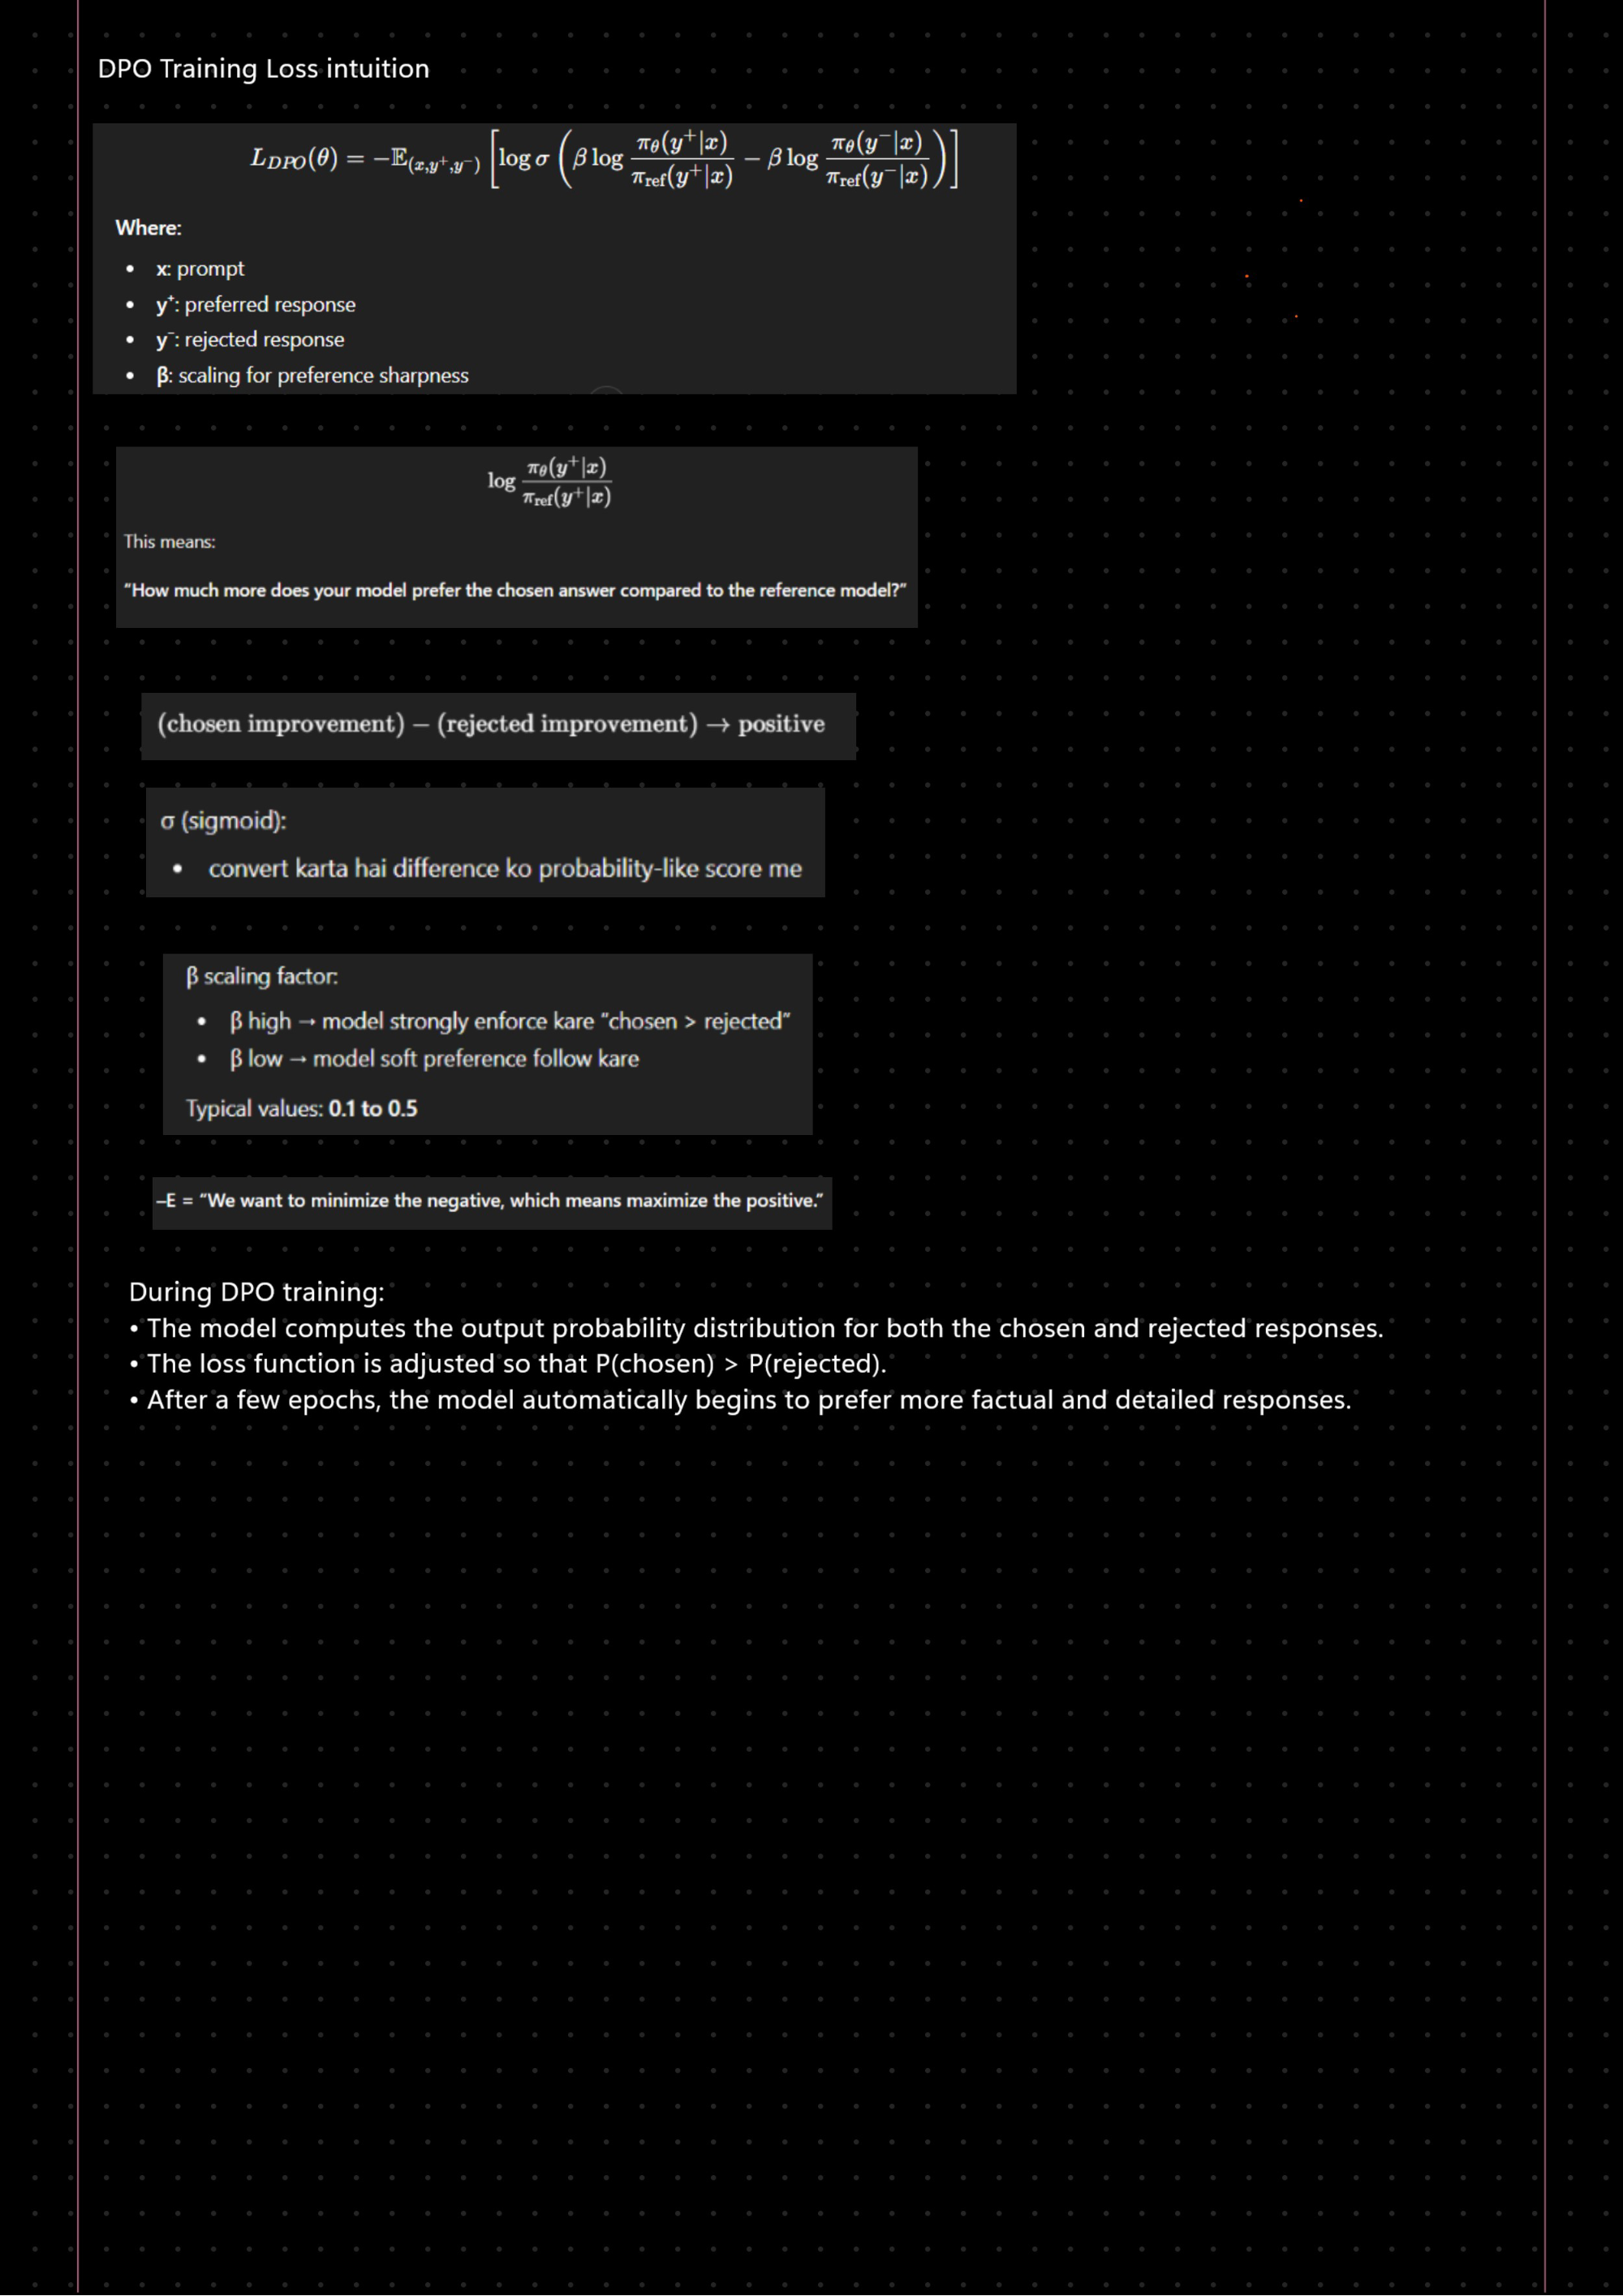

## DPO

In [6]:
# Import necessary libraries
import fitz
import re
import tf_keras as keras
from trl import DPOTrainer
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType

### Step1: Load the Model from Stage2

In [7]:
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [8]:
instruction_model = AutoModelForCausalLM.from_pretrained(stage2_model_path, device_map="auto")

instruction_model.eval()

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): lora.Linear(
            (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.05, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=2048, out_features=8, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=8, out_features=2048, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_embedding_B): ParameterDict()
            (lora_magnitude_vector): ModuleDict()
          )
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): lora.Linear(
            (base_layer): Linear(in_features=2048, out_features=256, bia

In [13]:
#prompt = "Explain how artificial intelligence is improving the process of drug discovery and development in the pharmaceutical industry."
prompt = "Impact of AI on pharmaceutical"

In [14]:
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

In [37]:
outputs = instruction_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.8,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.1
)

In [38]:
print("\nModel Output:\n")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Model Output:

Impact of AI on pharmaceutical R&D: a survey of industry leaders
Kimberly McDowell
Pharmacy and Pharmaceutical Sciences
Centre for Drug Research and Development
